In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import glob
import numpy as np
from IPython.display import display
import matplotlib.patheffects as pe

In [2]:
geo = pd.read_csv('/mnt/scratch/baburish/doublepulse/gnn/Analysis/data/geometry_clean.csv')
X = geo['dom_x']
Y = geo['dom_y']
Z = geo['dom_z']

In [3]:
connection = sqlite3.connect("/mnt/research/IceCube/lownutau/gemini_moreMC_sqlite/nutau_train/nutau_gemini_ftp_5TeV_lowerbound_skimmed_chunk_022860.010115_0000.db_train.db")
sql_query = """SELECT name FROM sqlite_master  
  WHERE type='table';"""
cursor = connection.cursor()
cursor.execute(sql_query)
output = cursor.fetchall()
print(output)

[('CleanedROIPulses',), ('truth',), ('reco',)]


In [4]:
df_truth = pd.read_sql_query("SELECT * FROM truth;", connection)
df_pulses = pd.read_sql_query("SELECT * FROM CleanedROIPulses;", connection)
df_reco = pd.read_sql_query("SELECT * FROM reco;", connection)
connection.close()

In [5]:
print(df_truth.columns)
print(df_pulses.columns)
print(df_reco.columns)

Index(['primary_energy', 'energy', 'position_x', 'position_y', 'position_z',
       'azimuth', 'zenith', 'pid', 'signal', 'sim_type', 'interaction_type',
       'run_id', 'subrun_id', 'event_id', 'subevent_id', 'inelasticity',
       'event_category', 'seed_string', 'tau_prod_vertex_x',
       'tau_prod_vertex_y', 'tau_prod_vertex_z', 'tau_prod_vertex_t',
       'tau_dec_vertex_x', 'tau_dec_vertex_y', 'tau_dec_vertex_z',
       'tau_dec_vertex_t', 'e_prod_vertex_x', 'e_prod_vertex_y',
       'e_prod_vertex_z', 'e_prod_vertex_t', 'mjd', 'TIntProbW', 'OneWeight',
       'Inelasticity_param_a', 'Inelasticity_param_b', 'MCPrimaryType',
       'MCPrimaryAzimuth', 'MCPrimaryEnergy', 'MCPrimaryZenith', 'Event',
       'SubEvent', 'IceScattering', 'IceAbsorption', 'DOMEfficiency',
       'IceAnisotropyScale', 'HoleIceForward_p0', 'HoleIceForward_p1',
       'MuonWeight', 'train_pass', 'event_no'],
      dtype='str')
Index(['charge', 'dom_time', 'dom_x', 'dom_y', 'dom_z', 'event_no'], dtype='st

In [6]:
print(df_truth['seed_string'].head())
print(df_pulses['dom_time'].head())

0    61.0
1    26.0
2    10.0
3    64.0
4    71.0
Name: seed_string, dtype: float64
0     538.0
1    1082.0
2     514.0
3    1716.0
4     184.0
Name: dom_time, dtype: float64


In [7]:
len(df_pulses)
len(df_truth)

8

In [8]:
df_truth.head()

,primary_energy,energy,position_x,position_y,position_z,azimuth,zenith,pid,signal,sim_type,...,SubEvent,IceScattering,IceAbsorption,DOMEfficiency,IceAnisotropyScale,HoleIceForward_p0,HoleIceForward_p1,MuonWeight,train_pass,event_no
0,1.030221e+07,7.019304e+03,-2.195232e+06,9.572290e+04,-4.172886e+06,3.098110,2.656983,16.0,1.0,genie,...,0.0,0.912106,1.064942,0.967198,None,0.220338,-0.001535,None,1.0,1
1,4.949892e+06,4.504551e+04,-5.136609e+05,-5.396813e+06,-4.781191e+06,4.617501,2.293575,-16.0,1.0,genie,...,0.0,0.971722,1.026946,0.929808,None,0.138536,-0.012791,None,1.0,7
2,4.782588e+07,2.488676e+04,-9.864655e+05,-2.546941e+06,-4.532804e+06,4.342797,2.599370,16.0,1.0,genie,...,0.0,0.945979,1.028540,0.961933,None,-0.070335,-0.029616,None,1.0,11
3,4.108625e+06,4.108625e+06,-1.113668e+03,8.735673e+02,1.947843e+03,2.702255,0.492489,16.0,1.0,genie,...,0.0,1.012143,1.010078,1.015390,None,0.184955,-0.113336,None,1.0,13
4,2.787516e+06,2.470473e+04,-1.909393e+05,-3.389982e+06,-4.099800e+06,4.656154,2.449818,16.0,1.0,genie,...,0.0,1.099751,0.908329,0.997731,None,-0.013001,-0.119427,None,1.0,14


In [9]:
df_pulses.head()

,charge,dom_time,dom_x,dom_y,dom_z,event_no
0,0.875,538.0,-358.44,120.56,174.67,1
1,0.275,1082.0,-358.44,120.56,157.65,1
2,1.175,514.0,-358.44,120.56,140.63,1
3,0.725,1716.0,-358.44,120.56,123.61,1
4,0.925,184.0,-234.95,140.44,193.69,1


In [10]:
grouped_piddf = df_truth.groupby('event_no').agg({
    'pid': lambda x: list(x),
}).reset_index()
grouped_piddf.rename(columns={
    'pid': 'pid',
}, inplace=True)

cols_to_convert = ['pid']

for col in cols_to_convert:
    grouped_piddf[col] = grouped_piddf[col].apply(lambda x: np.array(x))

grouped_df = df_pulses.groupby('event_no').agg({
    'charge': lambda x: list(x),
    'dom_x': lambda x: list(x),
    'dom_y': lambda x: list(x),
    'dom_z': lambda x: list(x),
    'dom_time': lambda x: list(x)
}).reset_index()

grouped_df.rename(columns={
    'charge': 'charge',
    'dom_x': 'dom_x',
    'dom_y': 'dom_y',
    'dom_z': 'dom_z',
    'dom_time': 'dom_time'
}, inplace=True)
cols_to_convert = ['charge', 'dom_x', 'dom_y', 'dom_z', 'dom_time']

for col in cols_to_convert:
    grouped_df[col] = grouped_df[col].apply(lambda x: np.array(x))
df = pd.merge(grouped_df, grouped_piddf, on='event_no', how='inner')

print(grouped_df.columns)
print(grouped_piddf.columns)
print(df.columns)
print(len(df['event_no'],))
print(len(df['pid'],))

Index(['event_no', 'charge', 'dom_x', 'dom_y', 'dom_z', 'dom_time'], dtype='str')
Index(['event_no', 'pid'], dtype='str')
Index(['event_no', 'charge', 'dom_x', 'dom_y', 'dom_z', 'dom_time', 'pid'], dtype='str')
8
8


In [11]:
display(df)

,event_no,charge,dom_x,dom_y,dom_z,dom_time,pid
0,1,"[0.8749999710992422, 0.2749999988660585, 1.174...","[-358.44, -358.44, -358.44, -358.44, -234.95, ...","[120.56, 120.56, 120.56, 120.56, 140.44, 140.4...","[174.67, 157.65, 140.63, 123.61, 193.69, 193.6...","[538.0, 1082.0, 514.0, 1716.0, 184.0, 194.0, 2...",[16.0]
1,7,"[0.5749999697583574, 1.3750000214947318, 1.024...","[-88.05, -88.05, -88.05, 35.54, 35.54, 35.54, ...","[-384.3, -384.3, -384.3, -364.83, -364.83, -36...","[176.62, 142.58, 125.56, 174.32, 157.3, 140.28...","[638.0, 805.0, 1324.0, 906.0, 973.0, 686.0, 97...",[-16.0]
2,11,"[1.4249998808559385, 0.12499999628897296, 0.92...","[-9.13, -9.13, -9.13, -9.13, -9.13, -9.13, -9....","[-481.74, -481.74, -481.74, -481.74, -481.74, ...","[346.05, 346.05, 346.05, 329.03, 312.01, 312.0...","[691.0, 789.0, 832.0, 620.0, 510.0, 925.0, 535...",[16.0]
3,13,"[1.0750000065620449, 1.1749999036527767, 1.124...","[-32.96, -32.96, 90.49, 90.49, 90.49, 90.49, 9...","[62.44, 62.44, 82.35, 82.35, 82.35, 82.35, 82....","[-440.33, -457.35, -417.46, -434.48, -434.48, ...","[1208.0, 1131.0, 1108.0, 1211.0, 1351.0, 1483....",[16.0]
4,14,"[0.17499999676856226, 0.9749999974167993, 0.77...","[-189.98, -189.98, -189.98, -189.98, -189.98, ...","[257.42, 257.42, 257.42, 257.42, 257.42, 276.9...","[-247.56, -247.56, -281.6, -315.64, -332.66, -...","[972.0, 998.0, 1054.0, 1629.0, 739.0, 515.0, 1...",[16.0]
5,20,"[0.6750000110324312, 0.774999932675924, 0.7250...","[-200.55, -200.55, -200.55, -200.55, -200.55, ...","[-74.03, -74.03, -74.03, -74.03, -74.03, -74.0...","[-157.41, -174.43, -225.49, -242.51, -242.51, ...","[1323.0, 844.0, 1317.0, 781.0, 1402.0, 815.0, ...",[16.0]
6,24,"[0.8749999710992422, 0.774999932675924, 0.2249...","[371.56, 371.56, 371.56, 371.56, 371.56, 371.5...","[-92.18, -92.18, -92.18, -92.18, -92.18, -92.1...","[-297.39, -331.43, -383.5, -399.52, -433.56, -...","[1373.0, 1675.0, 1390.0, 1056.0, 1729.0, 1351....",[16.0]
7,25,"[1.1249999565331392, 1.0249999674925947, 1.075...","[90.49, 90.49, 90.49, 90.49, 90.49, 195.03, 19...","[82.35, 82.35, 82.35, 82.35, 82.35, 125.59, 12...","[331.46, 297.42, 263.37, 246.35, 229.33, 382.6...","[1331.0, 1382.0, 1099.0, 1273.0, 1203.0, 935.0...",[-16.0]


In [12]:
duplicates = df[df.duplicated(subset=['event_no'])]
print(duplicates)

Empty DataFrame
Columns: [event_no, charge, dom_x, dom_y, dom_z, dom_time, pid]
Index: []


In [13]:
print(len(df['event_no'],))
print(len(df['pid'],))

8
8


In [14]:
%matplotlib inline
def flatten_list_column(col):
    flat_list = []
    for item in col:
        if isinstance(item, list):
            flat_list.extend(item)
        else:
            flat_list.append(item)
    return flat_list
# dfrow = df.iloc[10]
dfrow = df.iloc[df['charge'].apply(sum).idxmax()]
print(df['charge'].apply(sum).idxmax())
print(df_truth.iloc[df['charge'].apply(sum).idxmax()])
# print(dfrow['pid'])
dom_x_flat = flatten_list_column(dfrow['dom_x'])
dom_y_flat = flatten_list_column(dfrow['dom_y'])
dom_z_flat = flatten_list_column(dfrow['dom_z'])
charge_flat = flatten_list_column(dfrow['charge'])

df_redpulses = pd.DataFrame({
    'dom_x': dom_x_flat,
    'dom_y': dom_y_flat,
    'dom_z': dom_z_flat,
    'charge': charge_flat,
    'dom_time': flatten_list_column(dfrow['dom_time'])
})



charge_per_dom = df_redpulses.groupby(['dom_x', 'dom_y', 'dom_z'])['charge'].sum().reset_index()


3
primary_energy              4108625.427166
energy                      4108625.427166
position_x                    -1113.668165
position_y                      873.567334
position_z                     1947.842851
azimuth                           2.702255
zenith                            0.492489
pid                                   16.0
signal                                 1.0
sim_type                             genie
interaction_type                      -1.0
run_id                        2286010469.0
subrun_id                     4294967295.0
event_id                             344.0
subevent_id                            0.0
inelasticity                          None
event_category                         5.0
seed_string                           64.0
tau_prod_vertex_x                48.662634
tau_prod_vertex_y               327.305344
tau_prod_vertex_z              -445.600384
tau_prod_vertex_t              -292.983453
tau_dec_vertex_x                106.361541
tau_dec_v

53691532
47964143

In [15]:
dom_count = df_redpulses.groupby(['dom_x', 'dom_y', 'dom_z']).size().reset_index(name='count')
dom_count = dom_count[dom_count['count'] > 1]
print(dom_count)

      dom_x   dom_y   dom_z  count
3   -145.45  374.24 -503.14      4
4   -145.45  374.24 -485.12      4
5   -145.45  374.24 -468.10      2
6   -145.45  374.24 -451.08      4
7   -145.45  374.24 -434.06      4
..      ...     ...     ...    ...
161  303.41  335.64 -474.25      4
162  303.41  335.64 -457.23      6
163  303.41  335.64 -440.21      5
164  303.41  335.64 -423.19      3
165  303.41  335.64 -406.17      2

[127 rows x 4 columns]


In [16]:
min(df_redpulses['dom_time']) - min(df_redpulses['dom_time'])

0.0

dom_x    -437.040
dom_y     217.800
dom_z     161.050
charge      0.825
Name: 3, dtype: float64


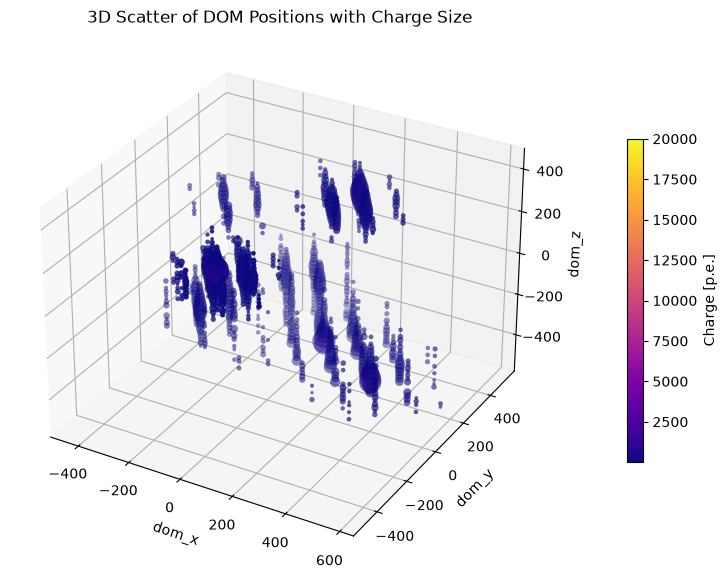

In [17]:
charge_per_dom = df_pulses.groupby(['dom_x', 'dom_y', 'dom_z'])['charge'].sum().reset_index()
charge_per_dom_row = charge_per_dom.iloc[3]
x, y, z, charge = charge_per_dom['dom_x'],charge_per_dom['dom_y'],charge_per_dom['dom_z'], charge_per_dom['charge']
print(charge_per_dom_row) 
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
# im2 = ax.scatter(X, Y, Z, marker='o', s=1)
im = ax.scatter(x, y, z, s=np.sqrt(charge * 100), c=charge, cmap='plasma', edgecolors='k',linewidths=0.1, zorder=100, vmax=20000)
ax.set_xlabel('dom_x')
ax.set_ylabel('dom_y')
ax.set_zlabel('dom_z')
ax.set_title('3D Scatter of DOM Positions with Charge Size')

cbar = plt.colorbar(im, ax=ax, shrink=0.6, pad=0.1)
cbar.set_label('Charge [p.e.]')

plt.show()

In [21]:
# Strings are identified by DOMs sharing the same (dom_x, dom_y); dom_z varies along a string.
charge_per_string = (df_redpulses
                      .groupby(['dom_x', 'dom_y'])['charge']
                      .sum()
                      .sort_values(ascending=False))

brightest_x, brightest_y = charge_per_string.index[0]
brightest_total_charge = charge_per_string.iloc[0]

string_pulses = (df_redpulses[(df_redpulses['dom_x'] == brightest_x) &
                               (df_redpulses['dom_y'] == brightest_y)]
                  .sort_values('dom_time')
                  .reset_index(drop=True))

print(f"event_no = {dfrow['event_no']}")
print(f"n_strings_hit = {len(charge_per_string)}")
print(f"brightest string: dom_x={brightest_x}, dom_y={brightest_y}, "
      f"total charge = {brightest_total_charge:.2f} p.e., "
      f"n_doms_on_string = {string_pulses['dom_z'].nunique()}, "
      f"n_pulses_on_string = {len(string_pulses)}")

string_pulses

event_no = 14
n_strings_hit = 18
brightest string: dom_x=54.26, dom_y=292.97, total charge = 2165.30 p.e., n_doms_on_string = 14, n_pulses_on_string = 458


,dom_x,dom_y,dom_z,charge,dom_time
0,54.26,292.97,-462.65,0.225000,-135.0
1,54.26,292.97,-445.63,16.025002,-126.0
2,54.26,292.97,-462.65,1.275000,-120.0
3,54.26,292.97,-445.63,36.224999,-120.0
4,54.26,292.97,-445.63,14.375000,-119.0
...,...,...,...,...,...
453,54.26,292.97,-462.65,1.025000,1921.0
454,54.26,292.97,-377.54,1.125000,1932.0
455,54.26,292.97,-309.46,0.725000,1950.0
456,54.26,292.97,-480.07,0.775000,1975.0


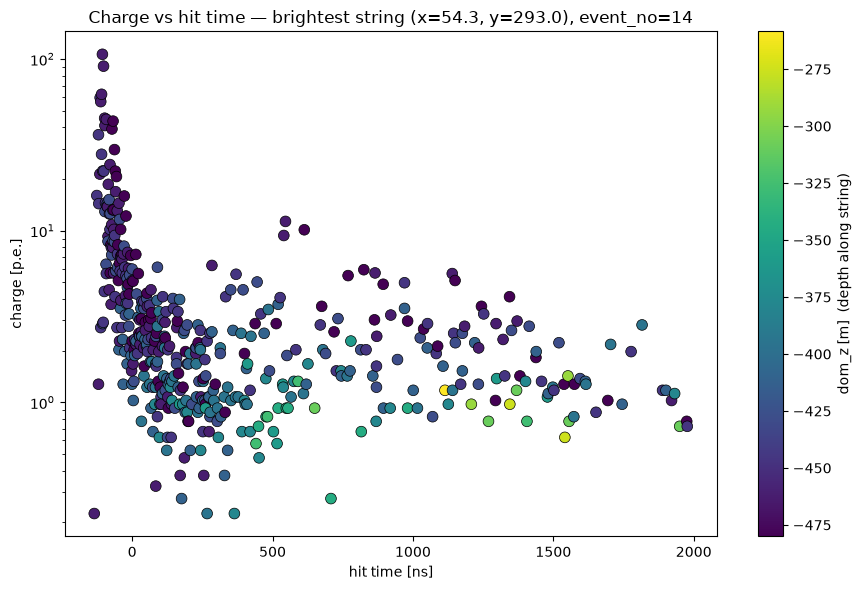

In [22]:
import matplotlib.colors as colors
fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(string_pulses['dom_time'], string_pulses['charge'],
                 c=string_pulses['dom_z'], cmap='viridis', #norm=colors.LogNorm(),
                 s=60, edgecolors='k', linewidths=0.5)
ax.set_xlabel('hit time [ns]')
ax.set_ylabel('charge [p.e.]')
ax.set_yscale('log')
ax.set_title(f"Charge vs hit time — brightest string "
             f"(x={brightest_x:.1f}, y={brightest_y:.1f}), event_no={dfrow['event_no']}")
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('dom_z [m]  (depth along string)')
plt.tight_layout()
plt.show()

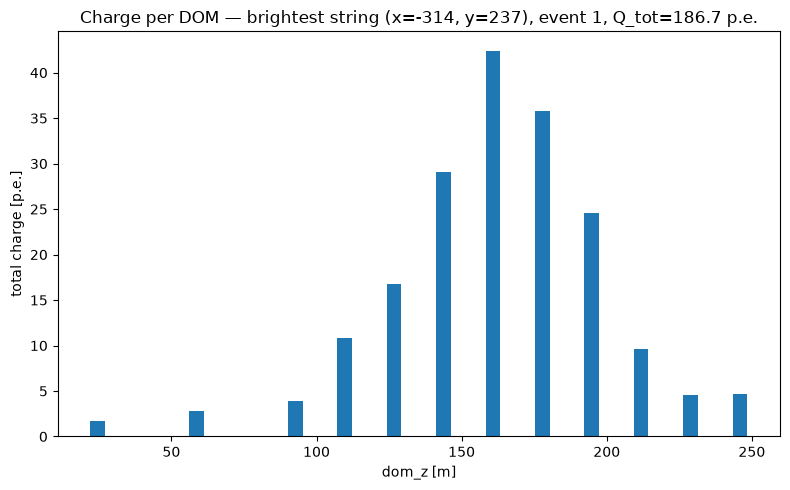

In [23]:
def brightest_string_pulses(event_no):
    dfrow = df[df['event_no'] == event_no].iloc[0]
    ev_pulses = pd.DataFrame({
        'dom_x': dfrow['dom_x'], 'dom_y': dfrow['dom_y'], 'dom_z': dfrow['dom_z'],
        'charge': dfrow['charge'], 'dom_time': dfrow['dom_time'],
    })
    charge_per_string = ev_pulses.groupby(['dom_x', 'dom_y'])['charge'].sum().sort_values(ascending=False)
    bx, by = charge_per_string.index[0]
    string_pulses = (ev_pulses[(ev_pulses['dom_x'] == bx) & (ev_pulses['dom_y'] == by)]
                      .sort_values('dom_time')
                      .reset_index(drop=True))
    return string_pulses, bx, by, charge_per_string.iloc[0]

event_no = df['event_no'].iloc[0]  # <- set the event to analyze

string_pulses, bx, by, total_q = brightest_string_pulses(event_no)

charge_per_dom_on_string = (string_pulses
                             .groupby('dom_z')['charge']
                             .sum()
                             .sort_index())

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(charge_per_dom_on_string.index, charge_per_dom_on_string.values, width=5)
ax.set_xlabel('dom_z [m]')
ax.set_ylabel('total charge [p.e.]')
ax.set_title(f'Charge per DOM — brightest string (x={bx:.0f}, y={by:.0f}), event {event_no}, Q_tot={total_q:.1f} p.e.')
plt.tight_layout()
plt.show()

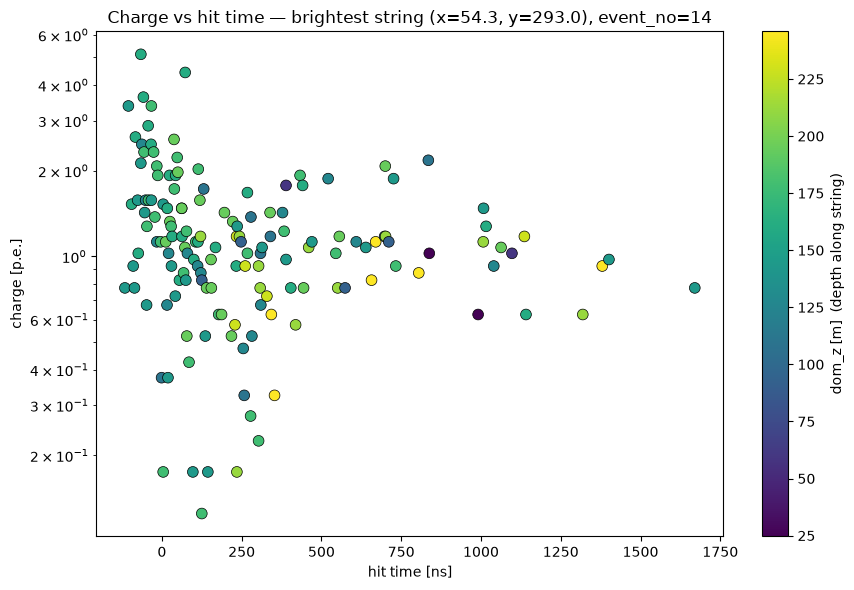

In [24]:
import matplotlib.colors as colors
fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(string_pulses['dom_time'], string_pulses['charge'],
                 c=string_pulses['dom_z'], cmap='viridis',# norm=colors.LogNorm(),
                 s=60, edgecolors='k', linewidths=0.5)
ax.set_xlabel('hit time [ns]')
ax.set_ylabel('charge [p.e.]')
ax.set_yscale('log')
ax.set_title(f"Charge vs hit time — brightest string "
             f"(x={brightest_x:.1f}, y={brightest_y:.1f}), event_no={dfrow['event_no']}")
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('dom_z [m]  (depth along string)')
plt.tight_layout()
plt.show()

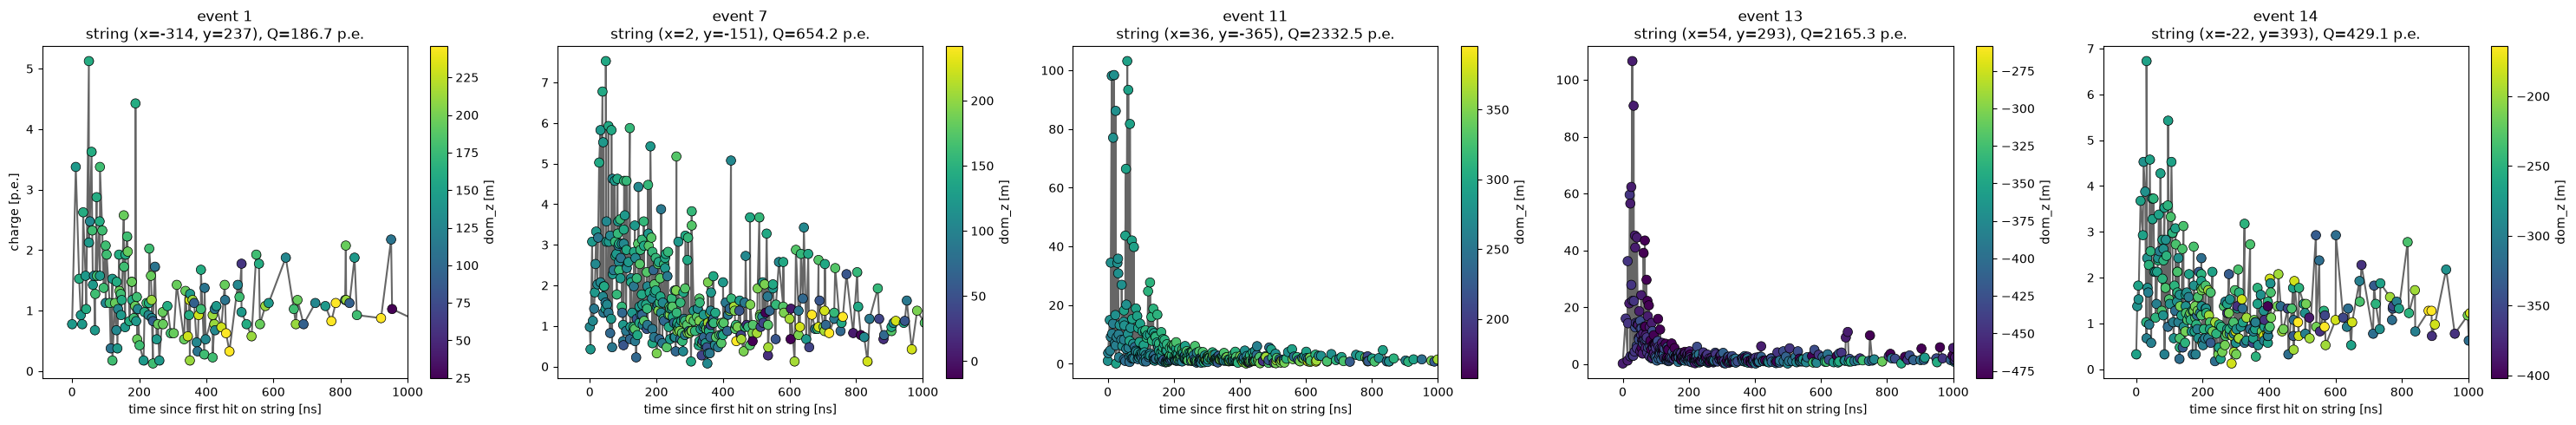

In [28]:
n_events = 5
charge_threshold = 0  # p.e. — drop any dom_z with a hit below this

event_list = df['event_no'].iloc[:n_events].tolist()

def brightest_string_pulses(event_no):
    dfrow = df[df['event_no'] == event_no].iloc[0]
    ev_pulses = pd.DataFrame({
        'dom_x': dfrow['dom_x'], 'dom_y': dfrow['dom_y'], 'dom_z': dfrow['dom_z'],
        'charge': dfrow['charge'], 'dom_time': dfrow['dom_time'],
    })
    charge_per_string = ev_pulses.groupby(['dom_x', 'dom_y'])['charge'].sum().sort_values(ascending=False)
    bx, by = charge_per_string.index[0]
    string_pulses = (ev_pulses[(ev_pulses['dom_x'] == bx) & (ev_pulses['dom_y'] == by)]
                      .sort_values('dom_time')
                      .reset_index(drop=True))
    return string_pulses, bx, by, charge_per_string.iloc[0]

n = len(event_list)
fig, axes = plt.subplots(1, n, figsize=(6 * n, 5), sharey=False)
if n == 1:
    axes = [axes]

for ax, ev in zip(axes, event_list):
    string_pulses, bx, by, total_q = brightest_string_pulses(ev)

    min_charge_per_dom = string_pulses.groupby('dom_z')['charge'].min()
    keep_doms = min_charge_per_dom[min_charge_per_dom >= charge_threshold].index
    string_pulses = string_pulses[string_pulses['dom_z'].isin(keep_doms)].reset_index(drop=True)

    shifted = string_pulses.copy()
    shifted['dom_time'] = string_pulses['dom_time'] - string_pulses['dom_time'].min()

    ax.plot(shifted['dom_time'], shifted['charge'], '-o', color='0.4', zorder=1)
    sc = ax.scatter(shifted['dom_time'], shifted['charge'],
                     c=string_pulses['dom_z'], cmap='viridis',
                     s=60, edgecolors='k', linewidths=0.5, zorder=2)
    ax.set_xlabel('time since first hit on string [ns]')
    # ax.set_yscale('log')
    ax.set_title(f"event {ev}\nstring (x={bx:.0f}, y={by:.0f}), Q={total_q:.1f} p.e.")
    fig.colorbar(sc, ax=ax, label='dom_z [m]')
    ax.set_xlim(right=1000)

axes[0].set_ylabel('charge [p.e.]')
plt.tight_layout()
plt.show()

selected 4 events with brightest-string charge > 1000 p.e.: [11, 13, 24, 25]


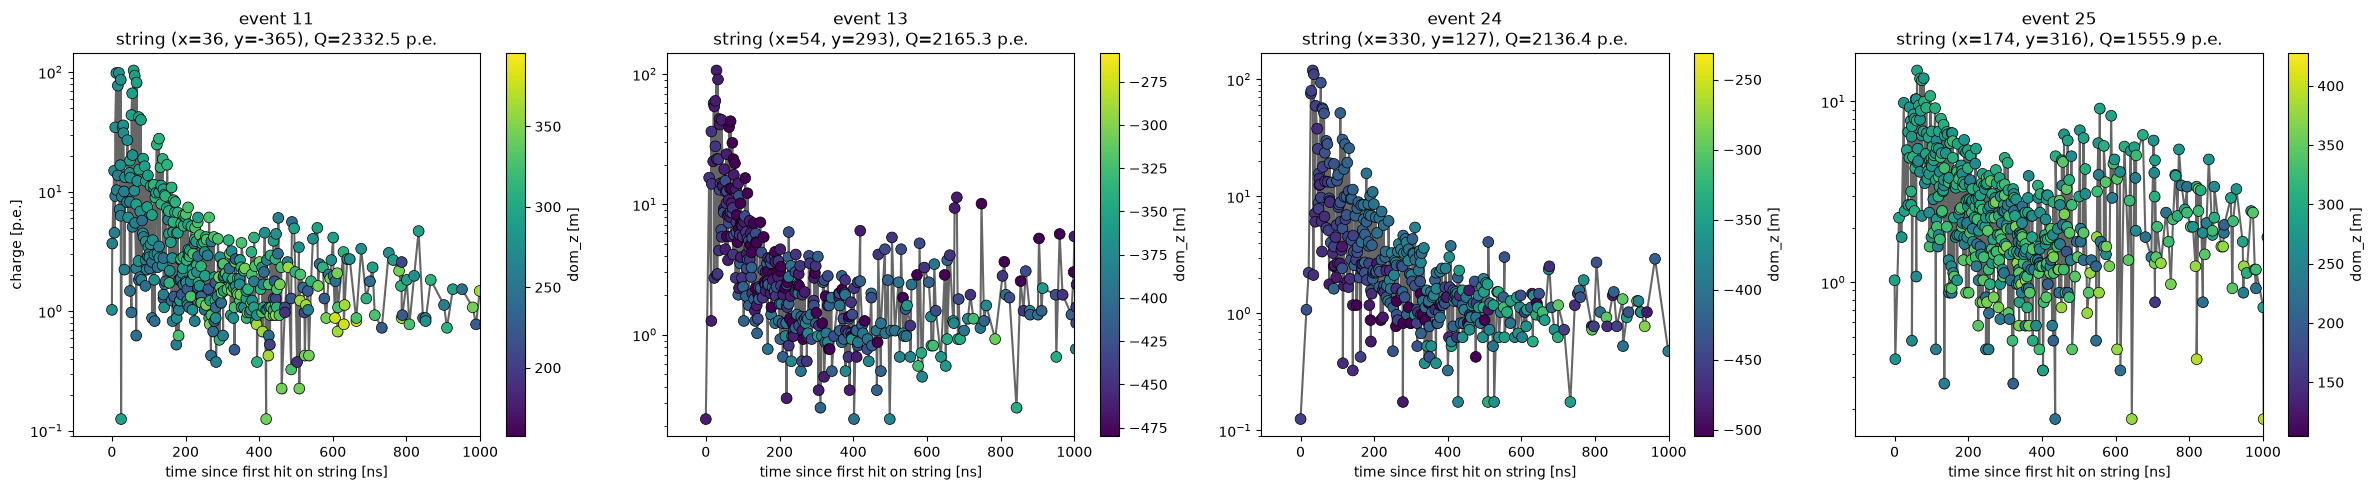

In [32]:
def brightest_string_pulses(event_no):
    dfrow = df[df['event_no'] == event_no].iloc[0]
    ev_pulses = pd.DataFrame({
        'dom_x': dfrow['dom_x'], 'dom_y': dfrow['dom_y'], 'dom_z': dfrow['dom_z'],
        'charge': dfrow['charge'], 'dom_time': dfrow['dom_time'],
    })
    charge_per_string = ev_pulses.groupby(['dom_x', 'dom_y'])['charge'].sum().sort_values(ascending=False)
    bx, by = charge_per_string.index[0]
    string_pulses = (ev_pulses[(ev_pulses['dom_x'] == bx) & (ev_pulses['dom_y'] == by)]
                      .sort_values('dom_time')
                      .reset_index(drop=True))
    return string_pulses, bx, by, charge_per_string.iloc[0]

n_events = 5
charge_threshold_event = 1000

event_list = []
for ev in df['event_no']:
    _, _, _, total_q = brightest_string_pulses(ev)
    if total_q > charge_threshold_event:
        event_list.append(ev)
    if len(event_list) == n_events:
        break

print(f"selected {len(event_list)} events with brightest-string charge > {charge_threshold_event} p.e.: {event_list}")

charge_threshold = 0  # p.e. — drop any dom_z with a hit below this

n = len(event_list)
fig, axes = plt.subplots(1, n, figsize=(6 * n, 5), sharey=False)
if n == 1:
    axes = [axes]

for ax, ev in zip(axes, event_list):
    string_pulses, bx, by, total_q = brightest_string_pulses(ev)

    min_charge_per_dom = string_pulses.groupby('dom_z')['charge'].min()
    keep_doms = min_charge_per_dom[min_charge_per_dom >= charge_threshold].index
    string_pulses = string_pulses[string_pulses['dom_z'].isin(keep_doms)].reset_index(drop=True)

    shifted = string_pulses.copy()
    shifted['dom_time'] = string_pulses['dom_time'] - string_pulses['dom_time'].min()

    ax.plot(shifted['dom_time'], shifted['charge'], '-o', color='0.4', zorder=1)
    sc = ax.scatter(shifted['dom_time'], shifted['charge'],
                     c=string_pulses['dom_z'], cmap='viridis',
                     s=60, edgecolors='k', linewidths=0.5, zorder=2)
    ax.set_xlabel('time since first hit on string [ns]')
    ax.set_yscale('log')
    ax.set_title(f"event {ev}\nstring (x={bx:.0f}, y={by:.0f}), Q={total_q:.1f} p.e.")
    fig.colorbar(sc, ax=ax, label='dom_z [m]')
    ax.set_xlim(right=1000)

axes[0].set_ylabel('charge [p.e.]')
plt.tight_layout()
plt.show()